In [16]:
import pandas as pd
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.sandbox.regression.predstd import wls_prediction_std
import scipy.stats
import pickle
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Data Pre-Processing

In [17]:
def cleanup(data):
    """
    Clean up CSV file output from Prolific experiment. 
    """
    fields = data.strip().split(',')
    fields = [field.strip('"').replace('\\', '').replace('{', '').replace('}', '').replace("'", '').replace("[", '').replace("]", '').replace('"', '') for field in fields]
    return fields

In [18]:
def parseCSV(filepath):
    """
    Parse rawdata CSV file saved from Prolific experiment. 
    """
    processed_data = []

    with open(filepath, 'r', encoding='utf-8') as file:
        for i,subj_data in enumerate(file):

            if i==0: continue # CSV headers

            processed_subj = cleanup(subj_data)

            subject_info = {
                'timestamp': processed_subj[4]
                }

            img_responses = []
            post_survey = {}
            resp = None

            for item in processed_subj[5:]:
                if ':' in item:
                    key, value = item.split(':', 1)

                    if key == 'response':
                        resp = value
                    elif key == 'image_name':
                        subject_info[os.path.basename(value)] = resp
                    else:
                        post_survey[key] = value

                # If subjects include newline character in post-survey comments
                else:
                    value = item
                    if resp and resp in post_survey:
                        post_survey[last_key] += ' ' + value

            subject_info.update(post_survey)
            processed_data.append(subject_info)

        # Create a DataFrame
        df = pd.DataFrame(processed_data)
        return df

In [19]:
def filter_subjects(df, attentioncheck):
    """
    Filter out subjects from the DataFrame based on the attention check. 
    Also filters out test runs of the experiment (labeled 'TEST' in post-survey comments). 
    If attentioncheck is true, filter based on attention check; otherwise, just remove test runs. 
    """

    df['agents'] = pd.to_numeric(df['agents'], errors='coerce')
    df['plates'] = pd.to_numeric(df['plates'], errors='coerce')
    if attentioncheck:
        filtered_df = df[(df['agents'] == 3) & (df['plates'] == 3) & (~df['comments'].str.contains("TEST", na=False))]
    else:
        filtered_df = df[(~df['comments'].str.contains("TEST", na=False))]
    return filtered_df

In [34]:
df = pd.read_csv("../rawdata/anon_expt3.csv")
filtered_df = filter_subjects(df, attentioncheck=True)
filtered_df

,timestamp,carrotcartoon_4_4.png,dishescartoon_6_1.png,dishescartoon_2_1.png,carrotcartoon_6_4.png,dishescartoon_2_8.png,carrotcartoon_4_8.png,dishescartoon_4_4.png,carrotcartoon_6_8.png,dishescartoon_6_8.png,...,agents,plates,language,enjoyment,assess,age,gender_cat,gender_text,education,comments
0,1738867927840,7.0,6.0,9.0,5.0,9,6.0,6,4.0,3,...,3,3,english,better,y,37.0,f,NaN,college,no
1,1738857071102,1.0,1.0,10.0,1.0,8,3.0,3,1.0,1,...,3,3,english,worse,y,51.0,f,NaN,college,NaN
2,1738867831198,2.0,1.0,2.0,1.0,10,2.0,4,1.0,9,...,3,3,English,average,y,39.0,m,NaN,some-college,NaN
3,1738867837022,2.0,4.0,10.0,3.0,10,2.0,5,3.0,4,...,3,3,english,average,y,47.0,f,NaN,some-college,NaN
4,1738867990717,5.0,1.0,1.0,2.0,10,5.0,5,2.0,3,...,3,3,English,better,y,54.0,m,NaN,some-college,I just thought if they would be a help or in t...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1738866411681,6.0,3.0,8.0,8.0,10,8.0,6,7.0,8,...,3,3,English,better,y,34.0,f,NaN,college,Yes. Role allocation.
296,1738865996361,1.0,1.0,8.0,1.0,10,2.0,8,1.0,1,...,3,3,English,better,y,27.0,f,NaN,some-college,NaN
297,1738866021543,1.0,1.0,10.0,1.0,10,1.0,6,1.0,9,...,3,3,English,average,y,35.0,m,NaN,college,I looked at how many carrots and plates were o...
298,1738868505481,8.0,8.0,8.0,9.0,10,9.0,9,9.0,9,...,3,3,English,average,y,24.0,f,NaN,grad,no


# Experiment 3 Analysis

In [39]:
def effect_code_workload(image_name):
    if '_1.png' in image_name:
        return [1, 0]
    elif '_4.png' in image_name:
        return [0, 0]
    elif '_8.png' in image_name:
        return [0, 1]
    else:
        return [None, None]

def effect_code_groupsize(image_name):
    if 'cartoon_2' in image_name:
        return [1, 0]
    elif 'cartoon_4' in image_name:
        return [0, 0]
    elif 'cartoon_6' in image_name:
        return [0, 1]
    else:
        return [None, None]

In [40]:
image_columns = [col for col in filtered_df.columns if col.endswith('.png')]

long_df = pd.melt(filtered_df, id_vars=['timestamp'], value_vars=image_columns, var_name='image', value_name='resp')
long_df[['x_1_1', 'x_1_2']] = pd.DataFrame(long_df['image'].apply(effect_code_workload).tolist(), index=long_df.index)
long_df[['x_2_1', 'x_2_2']] = pd.DataFrame(long_df['image'].apply(effect_code_groupsize).tolist(), index=long_df.index)

long_df = long_df.dropna(subset=['x_1_1', 'x_1_2', 'x_2_1', 'x_2_2'])
long_df['response'] = pd.to_numeric(long_df['resp'], errors='coerce')
long_df = long_df.dropna(subset=['response'])

model = smf.mixedlm("response ~ x_1_1 + x_1_2 + x_2_1 + x_2_2 + x_1_1:x_2_1 + x_1_1:x_2_2 + x_1_2:x_2_1 + x_1_2:x_2_2", long_df, groups=long_df["timestamp"])
result = model.fit()

print(result.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: response   
No. Observations: 5085    Method:             REML       
No. Groups:       284     Scale:              5.4796     
Min. group size:  11      Log-Likelihood:     -11869.2770
Max. group size:  18      Converged:          Yes        
Mean group size:  17.9                                   
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      4.543    0.138  32.918 0.000  4.272  4.813
x_1_1         -1.610    0.139 -11.554 0.000 -1.883 -1.337
x_1_2          0.825    0.139   5.921 0.000  0.552  1.098
x_2_1          3.042    0.139  21.838 0.000  2.769  3.315
x_2_2         -1.303    0.139  -9.351 0.000 -1.576 -1.030
x_1_1:x_2_1   -1.284    0.197  -6.515 0.000 -1.670 -0.898
x_1_1:x_2_2    1.176    0.197   5.965 0.000  0.790  1.562
x_1_2:x_2_1   -0.336    

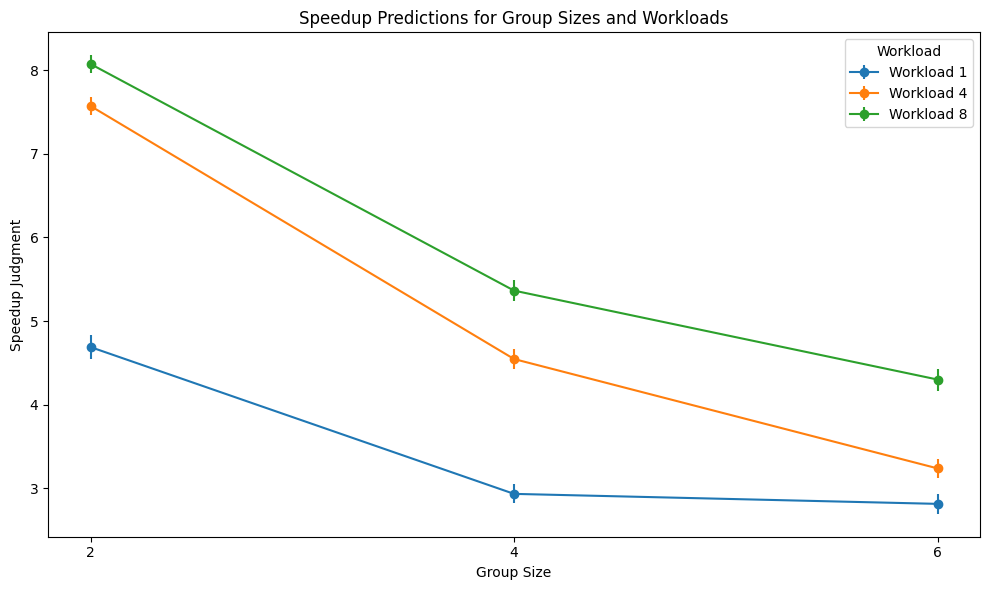

In [41]:
def standard_error(data):
    return scipy.stats.sem(data)

groupcoding = [
    (long_df['x_2_1'] == 1) & (long_df['x_2_2'] == 0), 
    (long_df['x_2_1'] == 0) & (long_df['x_2_2'] == 0), 
    (long_df['x_2_1'] == 0) & (long_df['x_2_2'] == 1) 
]

workloadcoding = [
    (long_df['x_1_1'] == 1) & (long_df['x_1_2'] == 0), 
    (long_df['x_1_1'] == 0) & (long_df['x_1_2'] == 0), 
    (long_df['x_1_1'] == 0) & (long_df['x_1_2'] == 1) 
]

long_df['GroupSize'] = np.select(groupcoding, [2,4,6], default=np.nan)
long_df['Workload'] = np.select(workloadcoding, [1,4,8], default=np.nan)

low_workload_data = long_df[long_df['x_1_1'] == 1]
med_workload_data = long_df[(long_df['x_1_1'] == 0) & (long_df['x_1_2'] == 0)]
high_workload_data = long_df[long_df['x_1_2'] == 1]

plt.figure(figsize=(10, 6))

# Plotting each workload with standard error
for data, label in zip([low_workload_data, med_workload_data, high_workload_data], ['Workload 1', 'Workload 4', 'Workload 8']):
    means = data.groupby('GroupSize')['response'].mean()
    sems = data.groupby('GroupSize')['response'].apply(standard_error)
    plt.errorbar(means.index, means, yerr=sems, label=label, fmt='-o')  # fmt specifies the line style and marker

plt.xlabel('Group Size')
plt.ylabel('Speedup Judgment')
plt.title('Speedup Predictions for Group Sizes and Workloads')
plt.legend(title='Workload')
plt.xticks([2,4,6])
plt.tight_layout()
plt.show()

In [42]:
def getSubjectStats(df):
    gender_counts = df['gender_cat'].value_counts()
    print(gender_counts)
    
    mean_age = pd.to_numeric(df['age'].replace('', float('nan')), errors='coerce').mean()
    print("Mean Age:", mean_age)

    sd_age = pd.to_numeric(df['age'].replace('', float('nan')), errors='coerce').std()
    print("SD Age:", sd_age)

In [43]:
alldata_df = filter_subjects(df, attentioncheck=True)
getSubjectStats(alldata_df)

gender_cat
f     145
m     132
nb      2
o       1
Name: count, dtype: int64
Mean Age: 41.41843971631206
SD Age: 14.242763551048863
